In [51]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [52]:
!unzip "/content/drive/MyDrive/car.zip" -d "/content/extracted_files"

Streaming output truncated to the last 5000 lines.
  inflating: /content/extracted_files/vehicle dataset/train/images/car12.jpg  
  inflating: /content/extracted_files/vehicle dataset/train/images/car120.jpg  
  inflating: /content/extracted_files/vehicle dataset/train/images/car121.jpg  
  inflating: /content/extracted_files/vehicle dataset/train/images/car122.jpg  
  inflating: /content/extracted_files/vehicle dataset/train/images/car123.jpg  
  inflating: /content/extracted_files/vehicle dataset/train/images/car124.jpg  
  inflating: /content/extracted_files/vehicle dataset/train/images/car125.jpg  
  inflating: /content/extracted_files/vehicle dataset/train/images/car127.jpg  
  inflating: /content/extracted_files/vehicle dataset/train/images/car128.jpg  
  inflating: /content/extracted_files/vehicle dataset/train/images/car130.jpg  
  inflating: /content/extracted_files/vehicle dataset/train/images/car132.jpg  
  inflating: /content/extracted_files/vehicle dataset/train/images/car

In [53]:
import os

# Define your base directory
base_dir = '/content/extracted_files/vehicle dataset'

# Define paths to your splits
train_dir = os.path.join(base_dir, 'train')
valid_dir = os.path.join(base_dir, 'valid')
classes_file = os.path.join(base_dir, 'classes.txt')

# Quick check: Print the classes/labels in your dataset
if os.path.exists(classes_file):
    with open(classes_file, 'r') as f:
        classes = f.read().splitlines()
    print(f"Detected Classes: {classes}")

Detected Classes: ['car', 'threewheel', 'bus', 'truck', 'motorbike', 'van']


In [54]:
!pip install ultralytics

In [55]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import os
import yaml

In [56]:
import yaml

# Define the dataset configuration
dataset_config = {
    'path': '/content/extracted_files/vehicle dataset',  # dataset root dir
    'train': 'train/images',  # train images (relative to path)
    'val': 'valid/images',    # val images (relative to path)

    # Classes dictionary
    'names': {i: cls for i, cls in enumerate(classes)}
}

# Save it as data.yaml
with open('/content/dataset.yaml', 'w') as f:
    yaml.dump(dataset_config, f, default_flow_style=False)

print("data.yaml created successfully!")

data.yaml created successfully!


In [57]:
from ultralytics import YOLO

# Load a pre-trained YOLO model (nano version is highly recommended for speed)
model = YOLO('yolov8n.pt')

# Train the model using your newly created data.yaml
results = model.train(
    data='/content/dataset.yaml', # Path to the yaml file you just created
    epochs=50,                    # Number of training epochs (adjust as needed)
    imgsz=640,                    # Image size
    device=0                      # Uses the Colab GPU (make sure your runtime type is set to GPU)
)

Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-23, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspec


image 1/1 /content/extracted_files/vehicle dataset/valid/images/00826.jpg: 448x640 1 car, 65.8ms
Speed: 4.0ms preprocess, 65.8ms inference, 4.7ms postprocess per image at shape (1, 3, 448, 640)


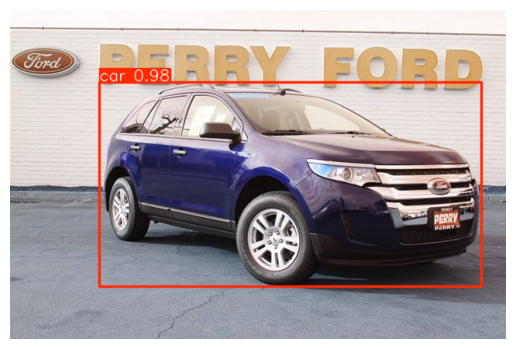

In [58]:
image_path = f"/content/extracted_files/vehicle dataset/valid/images/00826.jpg"

results = model(image_path)

for r in results:
    img = r.plot()

    import matplotlib.pyplot as plt
    plt.imshow(img)
    plt.axis('off')
    plt.show()


image 1/1 /content/extracted_files/vehicle dataset/valid/images/295200818_2befbc1651_m.jpg: 608x640 1 bus, 1 truck, 66.3ms
Speed: 7.4ms preprocess, 66.3ms inference, 1.8ms postprocess per image at shape (1, 3, 608, 640)


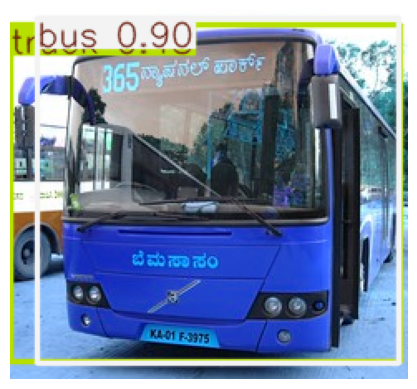


image 1/1 /content/extracted_files/vehicle dataset/valid/images/gettyimages-1156079540-612x612.jpg: 448x640 1 threewheel, 13.8ms
Speed: 3.4ms preprocess, 13.8ms inference, 3.2ms postprocess per image at shape (1, 3, 448, 640)


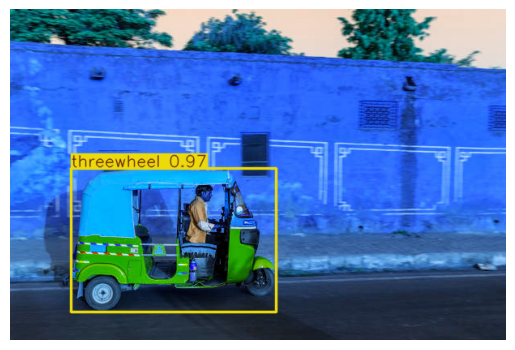


image 1/1 /content/extracted_files/vehicle dataset/valid/images/IY2ECPIUS9EU.jpg: 384x640 1 van, 70.2ms
Speed: 3.1ms preprocess, 70.2ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)


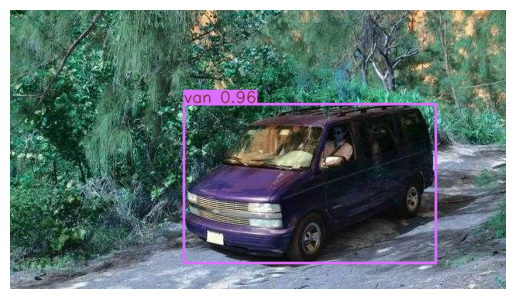


image 1/1 /content/extracted_files/vehicle dataset/valid/images/car137.jpg: 480x640 1 car, 81.7ms
Speed: 4.7ms preprocess, 81.7ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)


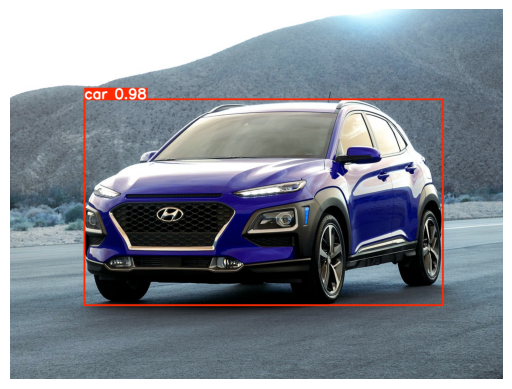


image 1/1 /content/extracted_files/vehicle dataset/valid/images/van162.jpeg: 256x640 1 van, 68.6ms
Speed: 4.0ms preprocess, 68.6ms inference, 2.0ms postprocess per image at shape (1, 3, 256, 640)


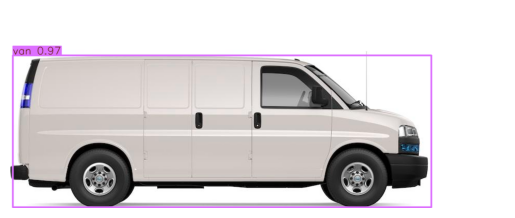


image 1/1 /content/extracted_files/vehicle dataset/valid/images/srilankatruck276.jpeg: 416x640 1 truck, 70.8ms
Speed: 8.4ms preprocess, 70.8ms inference, 1.8ms postprocess per image at shape (1, 3, 416, 640)


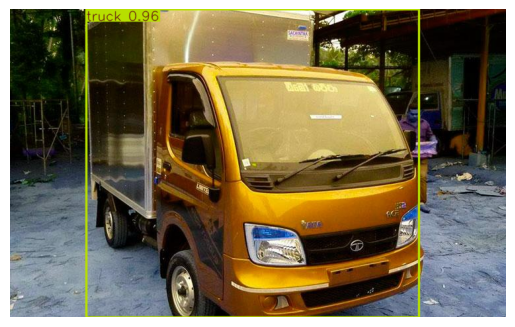


image 1/1 /content/extracted_files/vehicle dataset/valid/images/lorry256.jpeg: 480x640 1 truck, 13.3ms
Speed: 3.4ms preprocess, 13.3ms inference, 4.1ms postprocess per image at shape (1, 3, 480, 640)


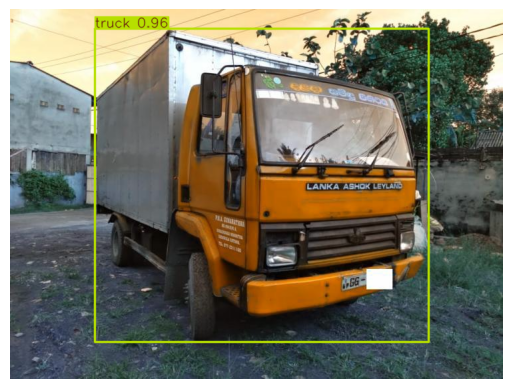


image 1/1 /content/extracted_files/vehicle dataset/valid/images/threewheel39.jpeg: 320x640 1 threewheel, 86.8ms
Speed: 2.5ms preprocess, 86.8ms inference, 1.8ms postprocess per image at shape (1, 3, 320, 640)


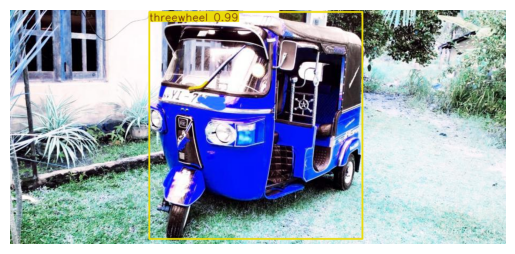


image 1/1 /content/extracted_files/vehicle dataset/valid/images/truck129.png: 640x640 1 truck, 15.3ms
Speed: 5.0ms preprocess, 15.3ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)


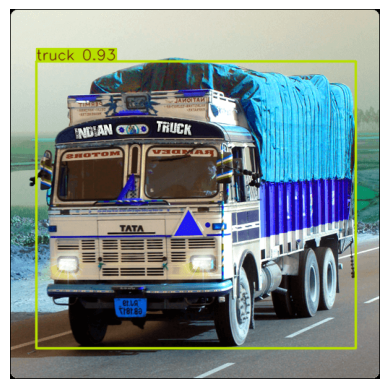

In [59]:
val_data = '/content/extracted_files/vehicle dataset/valid/images'

for i in range(0,9):
    img = val_data + '/' + os.listdir(val_data)[i]
    result = model(img)
    for r in result:
        img = r.plot()
        plt.imshow(img)
        plt.axis('off')
        plt.show()